<a href="https://colab.research.google.com/github/ryueuitae-blip/AIEYES-STUDY/blob/huisoo_branch/chapter3_titanic_01_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#분석환경 세팅

#시각화 결과를 별도의 창이 아닌 결과 셀에 표시
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #시각화 라이브러리
import seaborn as sns #matplotlib 기반의 시각화 라이브러리, 편의성 향

import warnings
warnings.filterwarnings('ignore') #코드 실행 시 불필요한 경고창 없애기


# **Titanic 데이터셋의 기본 정보**
### 데이터 피처

- Pclass: 승객 등급 (1등석,2등석,3등석)
- Survived: 생존 여부 (0 = 사망, 1 = 생존)
- Name: 이름
- Sex: 성별
- Age: 나이(세)
- Sibsp: 탑승한 형제/배우자 수
- Parch: 탑승한 부모/자녀 수
- Ticket: 티켓 번호
- Fare: 승객 운임(요금)
- Cabin: 선실 이름
- Embarked: 탑승 항구(C = 쉘 부르그, Q = 퀸즈타운, S = 사우스 햄튼)

##### 아래는 사용 데이터셋에 없는 피처
- body: 사망자 확인 번호
- home dest: 고향/목적지

In [2]:
#훈련 데이터와 테스트 데이터를 불러옴
df_train = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')

#처음으로부터 5개의 데이터를 조회해보기...
df_train.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#info()함수를 통해 데이터의 정보를 확인(칼럼명, NULL아닌 값 카운트, 자료형 등)
print(df_train.info())
print('-------------------------')
print(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 733 entries, 0 to 732
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  733 non-null    int64  
 1   Survived     733 non-null    int64  
 2   Pclass       733 non-null    int64  
 3   Name         733 non-null    object 
 4   Sex          733 non-null    object 
 5   Age          583 non-null    float64
 6   SibSp        733 non-null    int64  
 7   Parch        733 non-null    int64  
 8   Ticket       733 non-null    object 
 9   Fare         733 non-null    float64
 10  Cabin        168 non-null    object 
 11  Embarked     732 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 68.8+ KB
None
-------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  160 no

In [4]:
#불필요한 피처 제거(성별을 제외한 텍스트 피처 제거)
df_train = df_train.drop(['Name','Ticket','Cabin'],axis=1)
df_test = df_test.drop(['Name','Ticket','Cabin'],axis=1)

Survived
0    447
1    286
Name: count, dtype: int64


<Axes: xlabel='Survived'>

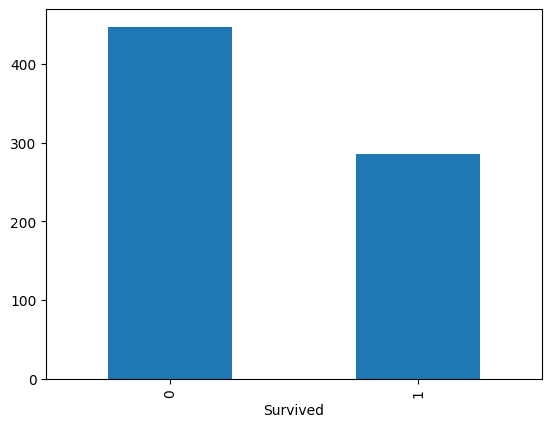

In [5]:
#탐색적 데이터 분석

#value_count(): 각 value가 얼마나 많은지 카운트
print(df_train['Survived'].value_counts())

#plot.bar()를 통해 막대그래프 형태로 그래프 출력
df_train['Survived'].value_counts().plot.bar()

Pclass
3    399
1    179
2    155
Name: count, dtype: int64


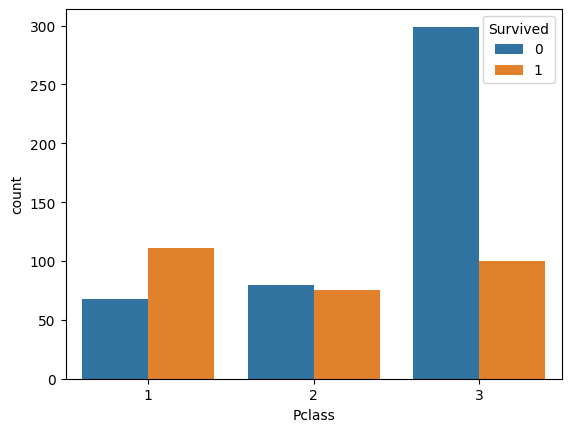

In [6]:
#Survived 피쳐를 기준으로 그룹을 나눈 후 그룹별 pclass 피쳐의 분포 확인

#Pclass에 따른 개수 확인
print(df_train['Pclass'].value_counts())

ax = sns.countplot(x='Pclass', hue='Survived', data=df_train)

#승객 등급이 낮을수록 생존 인원보다 사망 인원이 비교적 많은 씁쓸한 결과를 볼 수 있음

In [7]:
from scipy import stats

#두 집단의 피처를 비교하며 탐색작업을 자동화하는 함수 정의
def valid_features(df, col_name, distribution_check=True):

    #두 집단(Survived=1, Survived=0)의 분포 그래프를 출력
    g = sns.FacetGrid(df, col='Survived')
    g.map(plt.hist, col_name, bins = 30)

    #두 집단(Survived=1, Survived=0)의 표준편차를 각각 출력
    titanic_survived = df[df['Survived']==1]
    titanic_survived_static = np.array(titanic_survived[col_name])
    print("data std is", "%.2f" %np.std(titanic_survived_static))
    titanic_not_survived = df[df['Survived']==0]
    titanic_not_survived_static = np.array(titanic_not_survived[col_name])
    print("data std is", "%.2f" %np.std(titanic_not_survived_static))

    #T-test로 두 집단의 평균 차이 검정(ttest 함수 사용)
    tTestResult = stats.ttest_ind(titanic_survived[col_name], titanic_not_survived[col_name])
    tTestResultDiffVar = stats.ttest_ind(titanic_survived[col_name], titanic_not_survived[col_name], equal_var=False)
    print("The t-statistic and p-value assuming equal variances is %.3f and %.3f."%tTestResult)
    print("The t-statistic and p-value not assuming equal variances is %.3f and %.3f."%tTestResultDiffVar)

    if distribution_check:
        #Shapiro-Wilk 검정: 분포의 정규성 정도 검증
        print("The w-statistic and p-value for Survived is %.3f and %.3f."%stats.shapiro(titanic_survived[col_name]))
        print("The w-statistic and p-value for Not Survived is %.3f and %.3f."%stats.shapiro(titanic_not_survived[col_name]))

### Shapiro-Wilk 검정

주어진 데이터가 얼마나 정규성(정규분포)을 따르는지를 측정하는 검정 방법
대부분의 통계/데이터 분석은 데이터가 정규성을 띈다고 가정함 (T-test도 그러하다)

p-value > 0.05 => 정규분포를 따른다

p-value < 0.05 => 정규분포를 따르지 않는다

주의> 샘플 수가 너무 많으면(보통 5,000개 이상) 아주 작은 차이에도 p-value가 낮게 나오기도 함



### T-test

주어진 집단의 평균이 통계적으로 유의미하게 다른지 보는 테스트.

다음을 전제로 한다. 1. 정규성, 2. 등분산성


p-value < 0.05 => 두 집단의 평균은 차이가 있다.

p-value > 0.05 => 두 집단의 평균은 차이가 없다.

data std is 14.53
data std is 14.43
The t-statistic and p-value assuming equal variances is -2.006 and 0.045.
The t-statistic and p-value not assuming equal variances is -2.003 and 0.046.
The w-statistic and p-value for Survived is 0.982 and 0.004.
The w-statistic and p-value for Not Survived is 0.968 and 0.000.


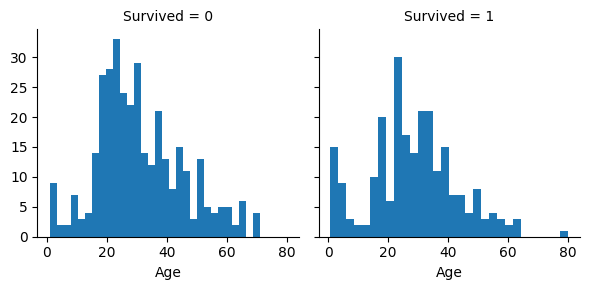

In [8]:
#나이가 0보다 클때, 생존자와 사망자 간 나이 분포 / T-test 결과 / 검정결과 반환
valid_features(df_train[df_train['Age'] > 0], "Age", distribution_check=True)

data std is 0.74
data std is 1.22
The t-statistic and p-value assuming equal variances is -0.776 and 0.438.
The t-statistic and p-value not assuming equal variances is -0.859 and 0.391.


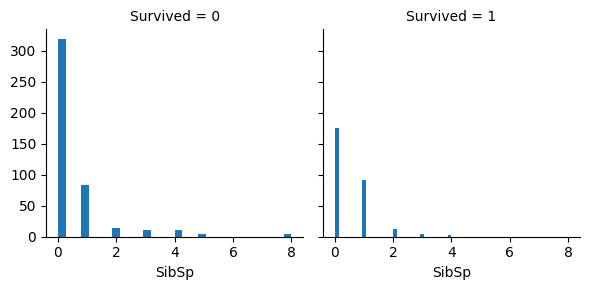

In [9]:
#SibSp 피쳐 탐색
valid_features(df_train, "SibSp", distribution_check=False)

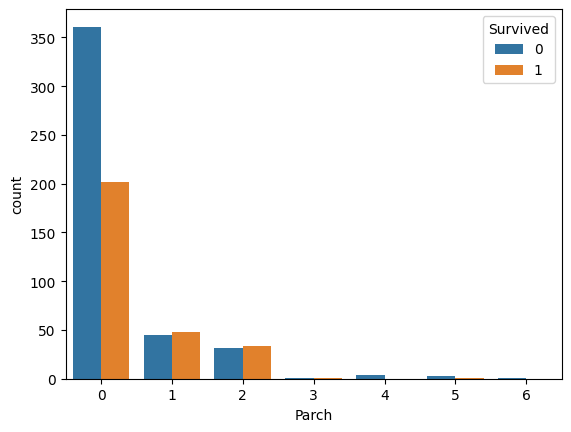

In [10]:
ax = sns.countplot(x='Parch', hue='Survived', data=df_train)

#탑승한 부모 자녀가 많을수록 사망 인원이 생존 인원보다 비교적 많음

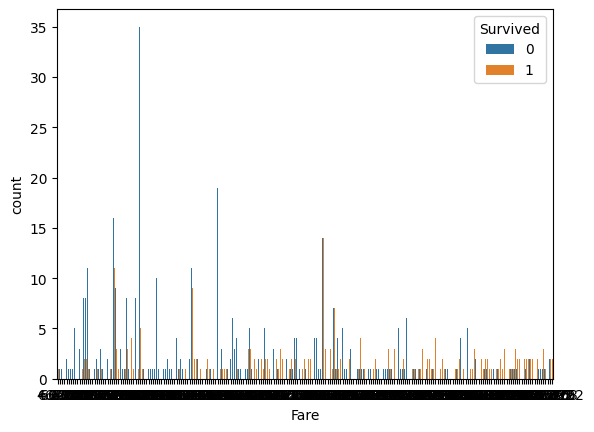

In [11]:
ax = sns.countplot(x='Fare', hue='Survived', data=df_train)

#높은 요금을 낸 승객이 그렇지 않은 승객보다 생존 비율이 더 높음

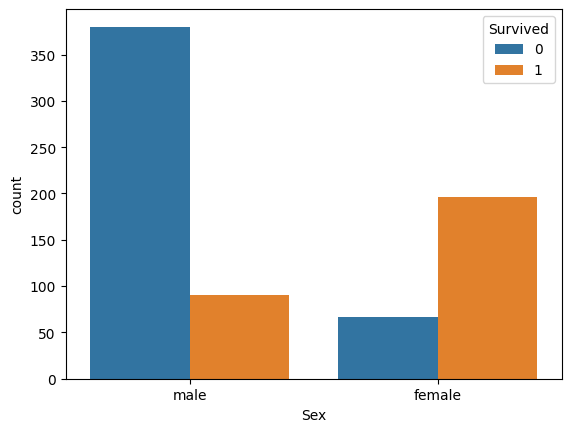

In [12]:
ax = sns.countplot(x='Sex', hue='Survived', data=df_train)

#남성은 사망 인원이 생존 인원보다 많고, 여성은 생존 인원이 사망 인원보다 많음

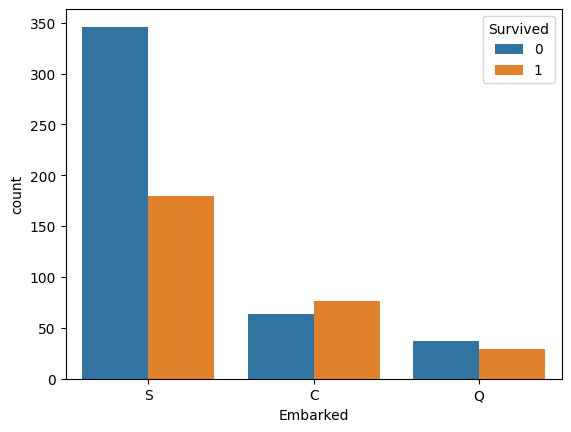

In [13]:
ax = sns.countplot(x='Embarked', hue='Survived', data=df_train)

#사우스 햄튼에서 승선한 인원이 대다수이며, 쉘 부르그의 승객들만 생존 인원이 사망 인원보다 많은 특징을 보임

### 생존자 분류 모델 만들기

In [14]:
from numpy._core.defchararray import replace
#결측치 처리

#Age: 결측값을 평균값으로 대체
replace_mean = df_train[df_train['Age'] > 0]['Age'].mean()
df_train['Age'] = df_train['Age'].fillna(replace_mean) #fillna() 결측치를 괄호 안 값으로 대체하는 메서드
df_test['Age'] = df_test['Age'].fillna(replace_mean)

#Embarked: 결측값을 최빈값으로 대체
embarked_mode = df_train['Embarked'].value_counts().index[0]
df_train['Embarked'] = df_train['Embarked'].fillna(embarked_mode)
df_test['Embarked'] = df_test['Embarked'].fillna(embarked_mode)

#Fare: 결측값을 평균값으로 대체 -> 모델 학습 시 NaN값 불허로 인해 추가
replace_mean = df_train[df_train['Fare'] > 0]['Fare'].mean()
df_train['Fare'] = df_train['Fare'].fillna(replace_mean)
df_test['Fare'] = df_test['Fare'].fillna(replace_mean)

#원-핫 인코딩을 위한 통합 데이터 프레임(whole_df) 생성
whole_df = pd.concat([df_train, df_test]) #강의 영상에서는 append를 사옹했으나 pandas 2.0부터는 append() 삭제, 대신 concat 이용
train_idx_num = len(df_train)

#pandas 패키지를 이용해 원-핫 인코딩 수행
whole_df_encoded = pd.get_dummies(whole_df)
df_train = whole_df_encoded[:train_idx_num]
df_test = whole_df_encoded[train_idx_num:]

df_train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,2,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,3,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,4,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,5,0,3,35.0,0,0,8.0500,False,True,False,False,True


In [15]:
#데이터를 학습 데이터셋, 테스트 데이터셋으로 분리
### 사용한 데이터셋의 test에 정답지가 없엇 train 파일을 4:1로 분리하여 각각 train, test 데이터로 사용함

x_train, y_train = df_train.loc[:,df_train.columns != 'Survived'].values, df_train['Survived'].values
x_test, y_test = df_test.loc[:,df_test.columns != 'Survived'].values, df_test['Survived'].values

In [71]:
#분류 모델링 - 로지스틱 회귀 (0~1 사이의 확률값 반환)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#학습
lr = LogisticRegression(random_state=0)
lr.fit(x_train, y_train)

#예측
y_pred = lr.predict(x_test)
y_pred_probability = lr.predict_proba(x_test)[:,1] #생존(1) 확률값만 뽑아내 저장

# 혼동행렬과 평가수치

TN: 실제 N & 예측 N

FP: 실제 N & 예측 P -> 1종 오류

FN: 실제 P & 예측 N -> 2종 오류

TP: 실제 P & 예측 P

---------------------

정확도(Accuracy): TP+TN/TP+TN+FP+FN -> 전체 예측 대비 옳은 예측의 비율

정밀도(Precision): TP/TP+FP -> P 예측 대비 실제 P 비율

재현도(Recall): TP/TP+FN -> 실제 P 대비 옳게 예측한 P 비율

특이도(Specificity): TN/TN+FP -> 실제 N 대비 옳게 예측한 N 비율

F1-score: 정밀도와 재현도의 조화평균
+ 분류 클래스 간 데이터 불균형이 심할 때 사용(정확도의 평가력이 떨어지기 때문)
+ 조화평균을 사용해 낮은 값에 더욱 민감!

F1 score = 2 x recall x precision / recall+precision


In [17]:
#테스트 데이터셋 평가 - accuracy, precision, recall, f1score
print('accuracy: %.2f' %accuracy_score(y_test, y_pred))
print('precision: %.3f' %precision_score(y_test, y_pred))
print('recall: %.3f' %recall_score(y_test, y_pred))
print('f1 score: %.3f' %f1_score(y_test, y_pred))

accuracy: 0.80
precision: 0.700
recall: 0.750
f1 score: 0.724


In [18]:
from sklearn.metrics import confusion_matrix

#혼동행렬 출력
con = confusion_matrix(y_true = y_test, y_pred = y_pred)
print(con)

# -> TN:86, FN:18, FP:14, TF:42

[[86 18]
 [14 42]]


AUC : 0.863


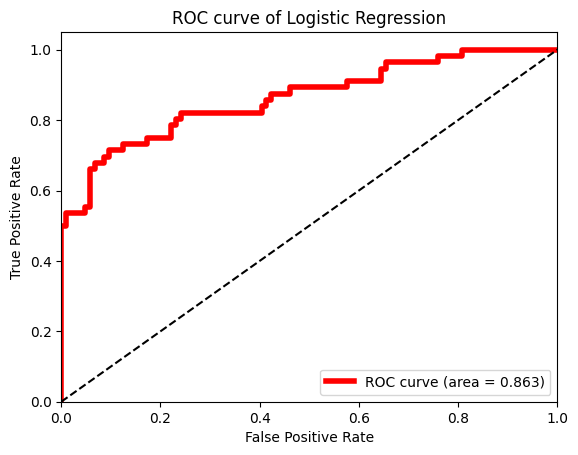

In [20]:
#AUC 곡선 확인하기

from sklearn.metrics import roc_curve,roc_auc_score

#AUC를 계산하여 출력
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_probability)
roc_auc = roc_auc_score(y_test, y_pred_probability) #확률로 된 예측값을 통하여 곡선을 그림
print('AUC : %.3f' %roc_auc)

#ROC curve를 그래프로 그려 출력
plt.plot(false_positive_rate, true_positive_rate, label='ROC curve (area = %0.3f)' %roc_auc, color='red', linewidth = 4.0)
plt.plot([0,1],[0,1],'k--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve of Logistic Regression')
plt.legend(loc = 'lower right')


#Decision Tree
피처 단위로 조건을 분리시켜 정담의 집합을 좁혀나가는 방법


In [22]:
#의사결정나무
from sklearn.tree import DecisionTreeClassifier

#의사결정나무 학습 및 테스트 데이터셋에 대한 예측값 반환
dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)
y_pred = dtc.predict(x_test)
y_pred_probability = dtc.predict_proba(x_test)[:,1]

#학습한 모델의 성능을 계산하여 출력
print('Accuracy: %.2f' % accuracy_score(y_test, y_pred))
print('Precion: %.3f' % precision_score(y_test, y_pred))
print('Recall: %.3f' % recall_score(y_test, y_pred))
print('F1 score: %.3f' % f1_score(y_test, y_pred))

Accuracy: 0.84
Precion: 0.826
Recall: 0.679
F1 score: 0.745


#모델 개선: 피쳐 엔지니어링의 첫걸음

**피쳐 엔지니어링이란?**

모델의 성능을 올리기 위해 피쳐의 형태를 가공하거나 텍스트 데이터처럼 분석에 사용 불가한 피쳐들을 계산 가능한 형태로 변환하는 것

In [62]:
#피쳐에서 새로운 의미 추출해내기

df_train = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')
df_train = df_train.drop(['Ticket'], axis=1)
df_test = df_test.drop(['Ticket'], axis=1)

#Age: 결측값을 평균값으로 대체
replace_mean = df_train[df_train['Age'] > 0]['Age'].mean()
df_train['Age'] = df_train['Age'].fillna(replace_mean)
df_test['Age'] = df_test['Age'].fillna(replace_mean)

#Embarked : 결측값을 최빈값으로 대체
embarked_mode = df_train['Embarked'].value_counts().index[0]
df_train['Embarked'] = df_train['Embarked'].fillna(embarked_mode)
df_test['Embarked'] = df_test['Embarked'].fillna(embarked_mode)

#one-hot 인코딩을 위해 통합 데이터 프레임 생성
whole_df = pd.concat([df_train,df_test])
train_idx_num = len(df_train)


**Cabin 피쳐 활용하기 - 특정 인덱스 정보만 추출**

In [63]:
#df에서 Cabin을 확인해보자
print(whole_df['Cabin'].value_counts()[:10])

#공통적으로 알파벳 + 숫자의 형태를 하고 있음.
#그렇다면 동일한 알파벳끼리 모아볼 수 있지 않을까?

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
E101           3
C22 C26        3
F33            3
C83            2
C123           2
Name: count, dtype: int64


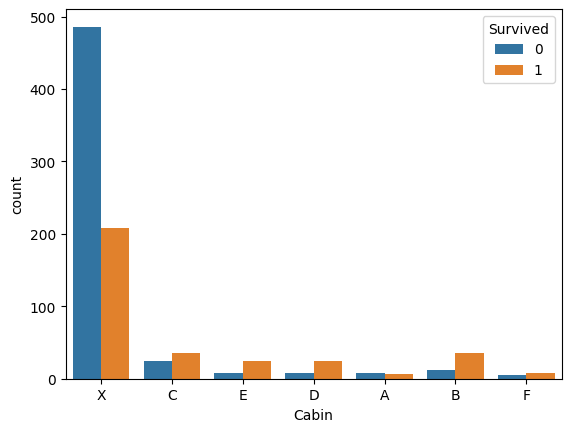

In [64]:
#확인해보자

#결측치는 'X'로 대체
whole_df['Cabin'] = whole_df['Cabin'].fillna('X')

#Cabin 피쳐의 첫 번째 문자만 추출
whole_df['Cabin'] = whole_df['Cabin'].apply(lambda x: x[0])

#숫자가 너무 작은 G와 T를 X로 대체
whole_df['Cabin'] = whole_df['Cabin'].replace({"G":"X","T":'X'})

ax = sns.countplot(x='Cabin', hue='Survived', data=whole_df)
plt.show()

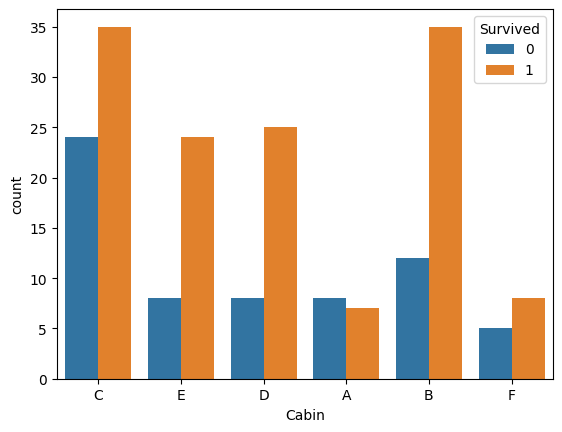

In [65]:
#스케일이 너무 커서 다른 알파벳의 수치가 잘 안보이므로 X만 제외하고 확인
ax = sns.countplot(x='Cabin', hue='Survived', data=whole_df[whole_df['Cabin'] != "X"])
plt.show()

**Name 피쳐 활용하기 - 특정 인덱스 정보만 추출**

In [66]:
whole_df['Name'].head()
#Mr. Mrs. 와 같은 호칭이 보인다. -> 사회적 계급의 단서?

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"


In [67]:
#이름에서 호칭을 추출
name_grade = whole_df['Name'].apply(lambda x: x.split(',',1)[1].split(".")[0])
#쉼표를 기준으로 한번만 자르고, 그중 인덱스 [1]인 문자열에 대해 마침표를 기준으로 자른 인덱스 [0]인 문자열을 반영
name_grade = name_grade.unique().tolist()
print(name_grade)

[' Mr', ' Mrs', ' Miss', ' Master', ' Don', ' Rev', ' Dr', ' Mme', ' Ms', ' Major', ' Lady', ' Sir', ' Mlle', ' Col', ' Capt', ' the Countess', ' Jonkheer']


In [68]:
#호칭에 따라 1910년대 기준 사회적 지위를 정의
grade_dict = {'Honorary': ['Rev','Col','Major','Dr','Capt','Sir'], #명예직 또는 전문직
              'Noble': ['Jonkheer', 'the Countess'], #귀족 또는 작위
              'Man': ['Mr', 'Don'], #남성
              'Boy': ['Master'], #미성년 남성
              'Woman_Married': ['Ms', 'Mme', 'Mrs', 'Dona'],  #기혼 여성
              'Woman_Single': ['Miss', 'Mile' 'Lady'] #미혼 여성
}

#호칭 기준에 따라서 name 피처를 딕셔너리 키대로 다시 정의하는 함수 give_grade() 생성
def give_grade(x):
    grade = x.split(",",1)[1].split(".")[0].strip() # strip()을 추가하여 앞뒤공백 정리
    for key,value in grade_dict.items():
        for title in value:
            if grade == title:
                return key
    return "G"

#위 함수를 적용하여 Name 피쳐를 새롭게 정의
whole_df['Name'] = whole_df['Name'].apply(lambda x: give_grade(x))
print(whole_df['Name'].value_counts())

Name
Man              520
Woman_Single     182
Woman_Married    127
Boy               40
Honorary          19
G                  3
Noble              2
Name: count, dtype: int64


 **one - hot encoding**

In [69]:
#pandas 패키지를 통해 one-hot 인코딩 수행

whole_df_encoded = pd.get_dummies(whole_df)
df_train = whole_df_encoded[:train_idx_num]
df_test = whole_df_encoded[train_idx_num:]
df_train.head()

#Cabin과 Name 피쳐에 대해 원 핫 인코딩이 수행되었음을 확인할 수 있다.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Name_Boy,Name_G,Name_Honorary,...,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_X,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False,...,False,False,True,False,False,False,False,True,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,5,0,3,35.0,0,0,8.0500,False,False,False,...,False,False,False,False,False,False,True,False,False,True


**피쳐 엔지니어링이 완료된 데이터셋을 통해 모델 학습시키기**

In [72]:
#데이터를 학습 데이터셋, 테스트 데이터셋으로 분리

x_train, y_train = df_train.loc[:,df_train.columns != 'Survived'].values, df_train['Survived'].values
x_test, y_test = df_test.loc[:,df_test.columns != 'Survived'].values, df_test['Survived'].values


#분류 모델링 - 로지스틱 회귀
#학습
lr = LogisticRegression(random_state=0)
lr.fit(x_train, y_train)

#예측결과 반환
y_pred = lr.predict(x_test)
y_pred_probability = lr.predict_proba(x_test)[:,1] #생존(1) 확률값만 뽑아내 저장

accuracy: 0.85
precision: 0.750
recall: 0.857
f1 score: 0.800
AUC : 0.896


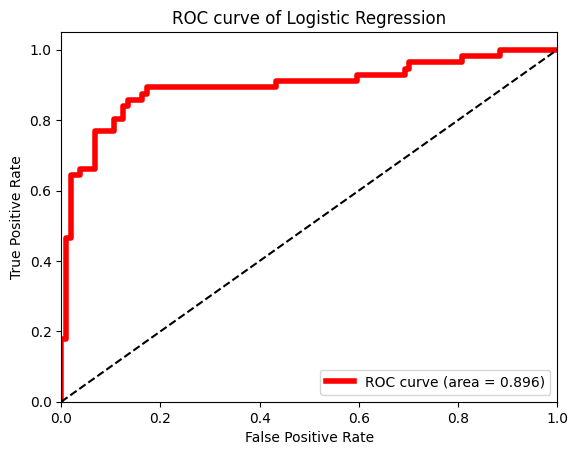

In [75]:
#테스트 데이터셋 평가
print('accuracy: %.2f' %accuracy_score(y_test, y_pred))
print('precision: %.3f' %precision_score(y_test, y_pred))
print('recall: %.3f' %recall_score(y_test, y_pred))
print('f1 score: %.3f' %f1_score(y_test, y_pred))


#AUC 곡선 확인하기
from sklearn.metrics import roc_curve,roc_auc_score

#AUC를 계산하여 출력
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred_probability)
roc_auc = roc_auc_score(y_test, y_pred_probability) #확률로 된 예측값을 통하여 곡선을 그림
print('AUC : %.3f' %roc_auc)

#ROC curve를 그래프로 그려 출력
plt.plot(false_positive_rate, true_positive_rate, label='ROC curve (area = %0.3f)' %roc_auc, color='red', linewidth = 4.0)
plt.plot([0,1],[0,1],'k--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve of Logistic Regression')
plt.legend(loc = 'lower right')

#이전 모델의 결과(하단에 서술)에 비해 전체적인 평가 수치가 꽤 상승한 것을 볼 수 있다.
#accuracy: 0.80
#precision: 0.700
#recall: 0.750
#f1 score: 0.724
#AUC : 0.863

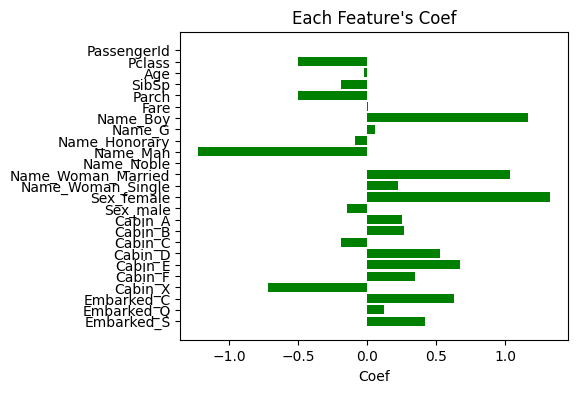

In [77]:
#피쳐별 영향력 확인하기

#예측 대상(정답)인 survived 피쳐를 제외한 모든 피쳐를 리스트로 반환(y축)
cols = df_train.columns.tolist()
cols.remove('Survived')
y_pos = np.arange(len(cols))

#각 피쳐별 회귀분석 계수를 그래프의 y축으로 한 피쳐 영향력 그래프 출력
plt.rcParams['figure.figsize'] = [5, 4]
fig, ax = plt.subplots()
ax.barh(y_pos, lr.coef_[0], align='center', color='green', ecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(cols)
ax.invert_yaxis()
ax.set_xlabel('Coef')
ax.set_title("Each Feature's Coef")

plt.show()

#Cabin과 Name이 생각보다 큰 영향력을 미침을 확인할 수 있음

# 모델 검증하기
1. K-fold
2. 학습곡선 분석

In [79]:
#K-fold 교차검증
from sklearn.model_selection import KFold

k = 5
cv = KFold(k, shuffle=True, random_state=0)
acc_history = []

# K-fold를 5(k)번의 분할 학습
for i, (train_data_row, test_data_row) in enumerate(cv.split(whole_df_encoded)):

    # 5개로 분할된 fold 중 4개를 학습 데이터셋, 1개를 테스트 데이터셋으로 지정(매 반복시마다 테스트 데이터셋 변경)
    df_train = whole_df_encoded.iloc[train_data_row]
    df_test = whole_df_encoded.iloc[test_data_row]

    # survived 피처를 y, 나머지 피처들을 x 데이터로 지정
    splited_x_train, splited_y_train = df_train.loc[:, df_train.columns != 'Survived'].values, df_train['Survived'].values
    splited_x_test, splited_y_test = df_test.loc[:, df_test.columns != 'Survived'].values, df_test['Survived'].values

    # 로지스틱 회귀 모델 학습
    lr = LogisticRegression(random_state=0)
    lr.fit(splited_x_train, splited_y_train)
    y_pred = lr.predict(splited_x_test)

    # 테스트 데이터셋의 Accuracy를 계산해 저장
    splited_acc = accuracy_score(splited_y_test, y_pred)
    acc_history.append(splited_acc)



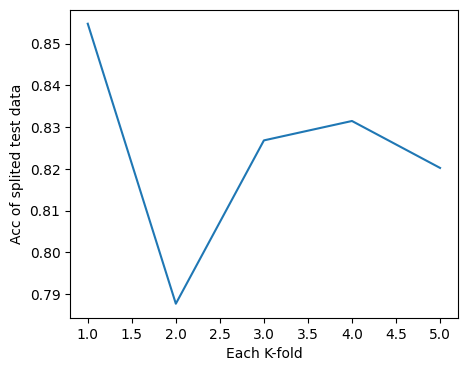

In [86]:
# acc_history에 저장된 5번의 학습 결과(Accuracy)를 그래프로 출력
plt.xlabel("Each K-fold")
plt.ylabel("Acc of splited test data")
plt.plot(range(1, k+1), acc_history)

#과적합 여부 -> 과적합까지는 아닌 것 같기도...

In [87]:
#패키지 설치
!pip install scipy==1.4.1
!pip install scikit-plot

  Using cached scipy-1.4.1.tar.gz (24.6 MB)
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [88]:
import scikitplot as skplt
skplt.estimators.plot_learning_curve(lr, x_train, y_train)
plt.show()

#왜 오류???

ImportError: cannot import name 'interp' from 'scipy' (/usr/local/lib/python3.12/dist-packages/scipy/__init__.py)